In [88]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from agent import Agent
from data.read_data import read_data
from simulation import SimulationConfig, Simulation
from filters import NoOpFilter, MaximumLikelihoodEstimator

In [89]:
data_dict = read_data()
K, L, num_links, num_agents, noise_covariance, dt, initial_positions, target_positions = data_dict.values()

# Configuration with no filter
num_steps = 50_000
config = SimulationConfig(
    noise_covariance=noise_covariance,
    filter=MaximumLikelihoodEstimator(),
    desc='Noisy, MLE 30',
    dt=dt,
    T=30
)

In [90]:
seed = np.random.randint(0, 100000)
agents = [
    Agent(id=i, initial_position=initial_positions[i], target_position=target_positions[i], filter=config.filter) 
    for i in range(num_agents)
]

position_history = np.zeros((num_steps + 1, num_agents, 2))
position_history[0, :, :] = initial_positions

sim = Simulation(agents=agents, L=L, config=config, seed=seed)
sim.error_history = np.zeros(num_steps)

for step in range(num_steps):
    sim._step()
    for i, agent in enumerate(agents):
        position_history[step + 1, i, :] = agent.position

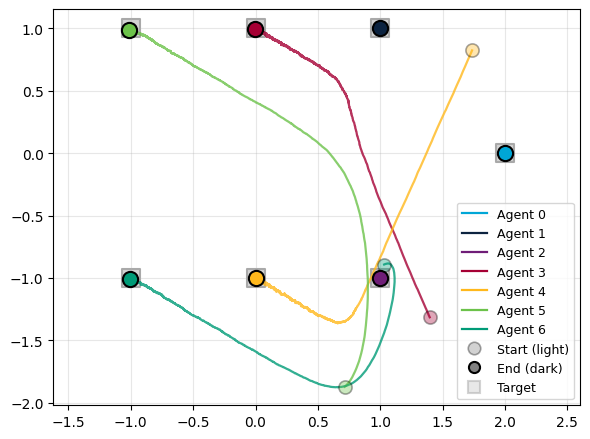

In [91]:
from matplotlib.lines import Line2D

plt.figure(figsize=(6, 4.5))
plt.tick_params(labelsize=10)
plt.grid(True, alpha=0.3)

colors = ['#00A6D6', '#0C2340', '#6F1D77', '#A50034', '#FFB81C', '#6CC24A', '#009B77']
for i in range(num_agents):
    plt.plot(position_history[:, i, 0], position_history[:, i, 1],
             color=colors[i], linewidth=1.6, alpha=0.8, label=f'Agent {i} path')
    plt.scatter(target_positions[i, 0], target_positions[i, 1],
                s=150, c='lightgray', marker='s', edgecolors='darkgray',
                linewidths=1.5, alpha=1, zorder=1)
    plt.scatter(position_history[0, i, 0], position_history[0, i, 1],
                s=90, c=[colors[i]], marker='o', edgecolors='black',
                linewidths=1.2, alpha=0.35, zorder=10)
    plt.scatter(position_history[-1, i, 0], position_history[-1, i, 1],
                s=120, c=[colors[i]], marker='o', edgecolors='black',
                linewidths=1.5, zorder=11)

legend_elements = [Line2D([0], [0], color=colors[i], label=f'Agent {i}', linewidth=1.6) for i in range(num_agents)]
legend_elements.append(Line2D([0], [0], marker='o', color='w', label='Start (light)',
                              markerfacecolor='gray', markeredgecolor='black',
                              markeredgewidth=1.2, markersize=9, alpha=0.35))
legend_elements.append(Line2D([0], [0], marker='o', color='w', label='End (dark)',
                              markerfacecolor='gray', markeredgecolor='black',
                              markeredgewidth=1.5, markersize=8))
legend_elements.append(Line2D([0], [0], marker='s', color='w', label='Target',
                              markerfacecolor='lightgray', markeredgecolor='darkgray',
                              markeredgewidth=1.5, markersize=9, alpha=0.5))

plt.legend(handles=legend_elements, loc='best', fontsize=9, ncol=1)
plt.axis('equal')
plt.tight_layout()
plt.savefig('agent_position_trajectories.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()


C:\Users\henlu\AppData\Local\Temp\ipykernel_29164\3167415720.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


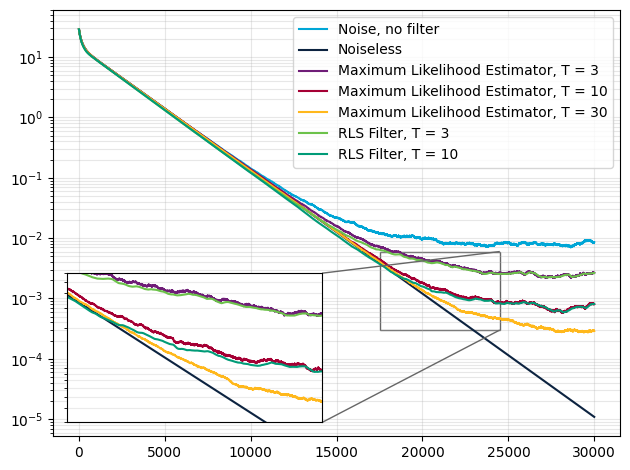

In [80]:
from itertools import cycle
import numpy as np
import matplotlib.pyplot as plt

from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from matplotlib.patches import Ellipse
from matplotlib.patches import ConnectionPatch

K_MAX = 30_000

files = [
    'results/noise_no_filter.npy',
    'results/Noiseless.npy',
    'results/mle3.npy',
    'results/mle10.npy',
    'results/mle30.npy',
#    'results/rls1.npy',
    'results/rls3.npy',
    'results/rls10.npy',
#    'results/rls30.npy',
]
error_dict = {}
for file in files:
    data = np.load(file, allow_pickle=True).item()
    error_dict.update(data)

color_cycle = cycle(['#00A6D6', '#0C2340', '#6F1D77', '#A50034', '#FFB81C', '#6CC24A', '#009B77'])

fig, ax = plt.subplots()

# --- main plot ---
for config_name, errors in error_dict.items():
    arr = np.array(errors)[:, :K_MAX]
    mean_error = np.mean(arr, axis=0)

    color = next(color_cycle)
    ax.plot(range(len(mean_error)), mean_error, label=config_name, color=color)

ax.tick_params(labelsize=10)
ax.grid(True, alpha=0.3, which='both')
ax.set_yscale('log')
ax.legend()

# --- "magnifying glass" parameters ---
x0, y0 = 21000, 3e-3
x1, x2 = x0 - 3500, x0 + 3500
y1, y2 = 0.1 * y0, 2 * y0

# --- inset axes (the zoomed view) ---
axins = inset_axes(ax, width="45%", height="35%", loc="lower left", borderpad=1)

# replot same curves into inset
color_cycle2 = cycle(['#00A6D6', '#0C2340', '#6F1D77', '#A50034', '#FFB81C', '#6CC24A', '#009B77'])
for config_name, errors in error_dict.items():
    arr = np.array(errors)[:, :K_MAX]
    mean_error = np.mean(arr, axis=0)
    axins.plot(range(len(mean_error)), mean_error, color=next(color_cycle2))

axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
axins.set_yscale('log')
axins.grid(True, alpha=0.25, which='both')
axins.set_xticks([])
axins.set_yticks([])

# draw the rectangle on main plot + connectors (optional but usually nice)
mark_inset(ax, axins, loc1=1, loc2=4, fc="none", ec="0.4", lw=1.0)


fig.tight_layout()
fig.savefig('squared_error_convergence.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()
